### Setup

In [44]:
!./venv/bin/pip install kaggle scikit-learn numpy matplotlib seaborn


zsh:1: ./venv/bin/pip: bad interpreter: /Users/maxim/Documents/work/sigmoid_hw/11_Hyperparameter_Tuning/12_GMM_EM_KMeans/venv/bin/python3.13: no such file or directory


In [45]:
!kaggle datasets download --unzip -d imakash3011/customer-personality-analysis

zsh:1: /Users/maxim/Documents/work/sigmoid_hw/12_GMM_EM_KMeans/venv/bin/kaggle: bad interpreter: /Users/maxim/Documents/work/sigmoid_hw/11_Hyperparameter_Tuning/12_GMM_EM_KMeans/venv/bin/python3.13: no such file or directory


### Imports

In [162]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import figure
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Load Dataset

In [47]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [48]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [49]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [50]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [51]:
df.drop("ID", axis=1, inplace=True)

### Plot Distros

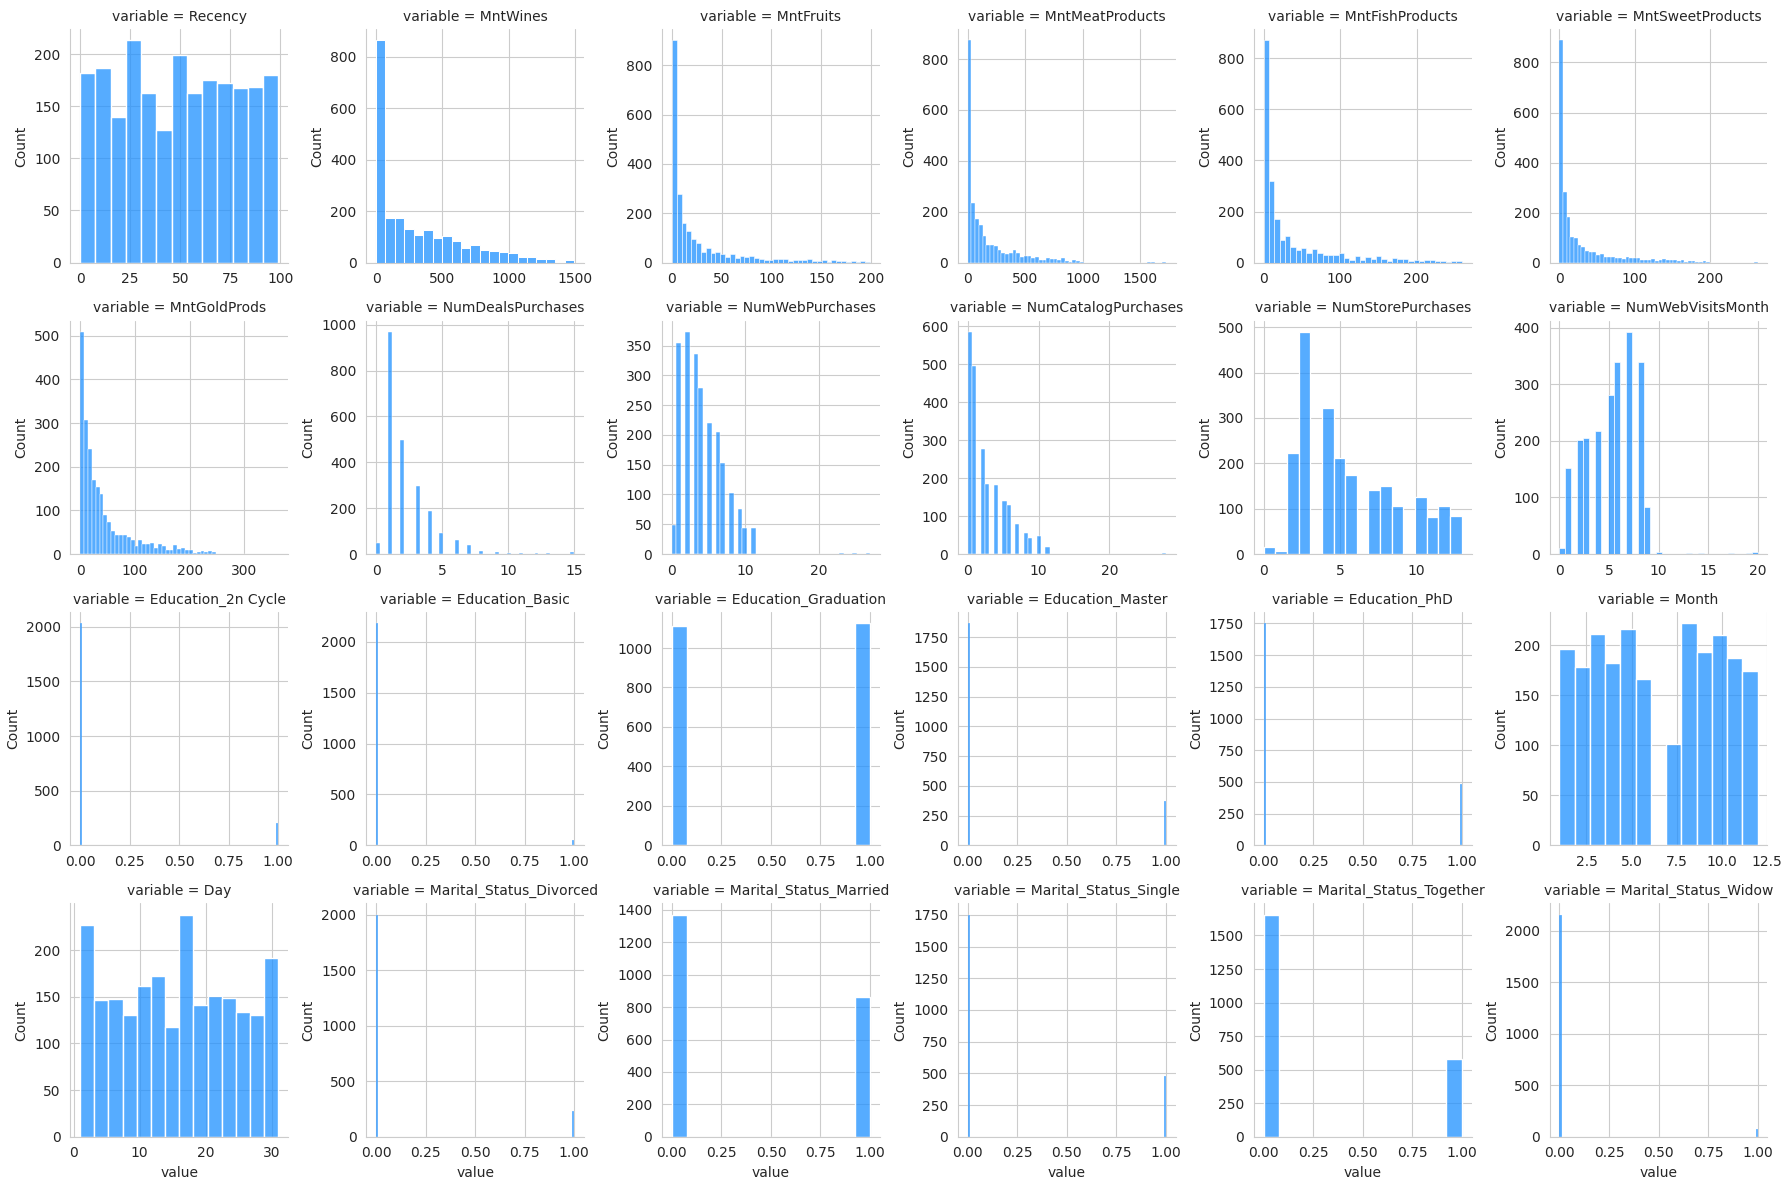

In [113]:
# count_cols = ["Marital_Status", "Year", "Education", "Kidhome", "Teenhome", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain", "Response"]
count_cols = ["Year", "Kidhome", "Teenhome", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain", "Response"]
kde_cols = ["Year_Birth", "Income"]
hist_cols = df.drop(columns=kde_cols + count_cols)

with sns.axes_style('whitegrid'):
  nd = pd.melt(df, value_vars=hist_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=6, sharex=False, sharey=False)
  n1 = n1.map(sns.histplot, 'value', color='#1e90ff')

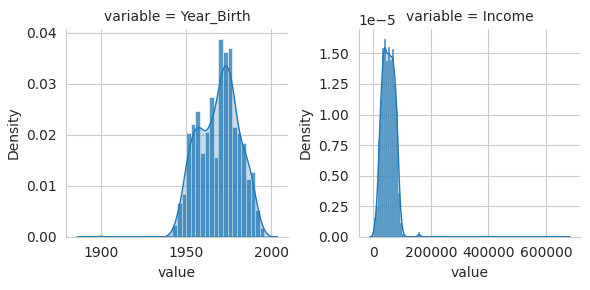

In [114]:
with sns.axes_style('whitegrid'):
  nd = pd.melt(df, value_vars=kde_cols)
  n1 = sns.FacetGrid(nd, col='variable', sharex=False, sharey=False)

  n1.map(
      sns.histplot,
      'value',
      stat='density',
  )

  n1.map(
      sns.kdeplot,
      'value',
      fill=True
  )

/Users/maxim/Documents/work/sigmoid_hw/12_GMM_EM_KMeans/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


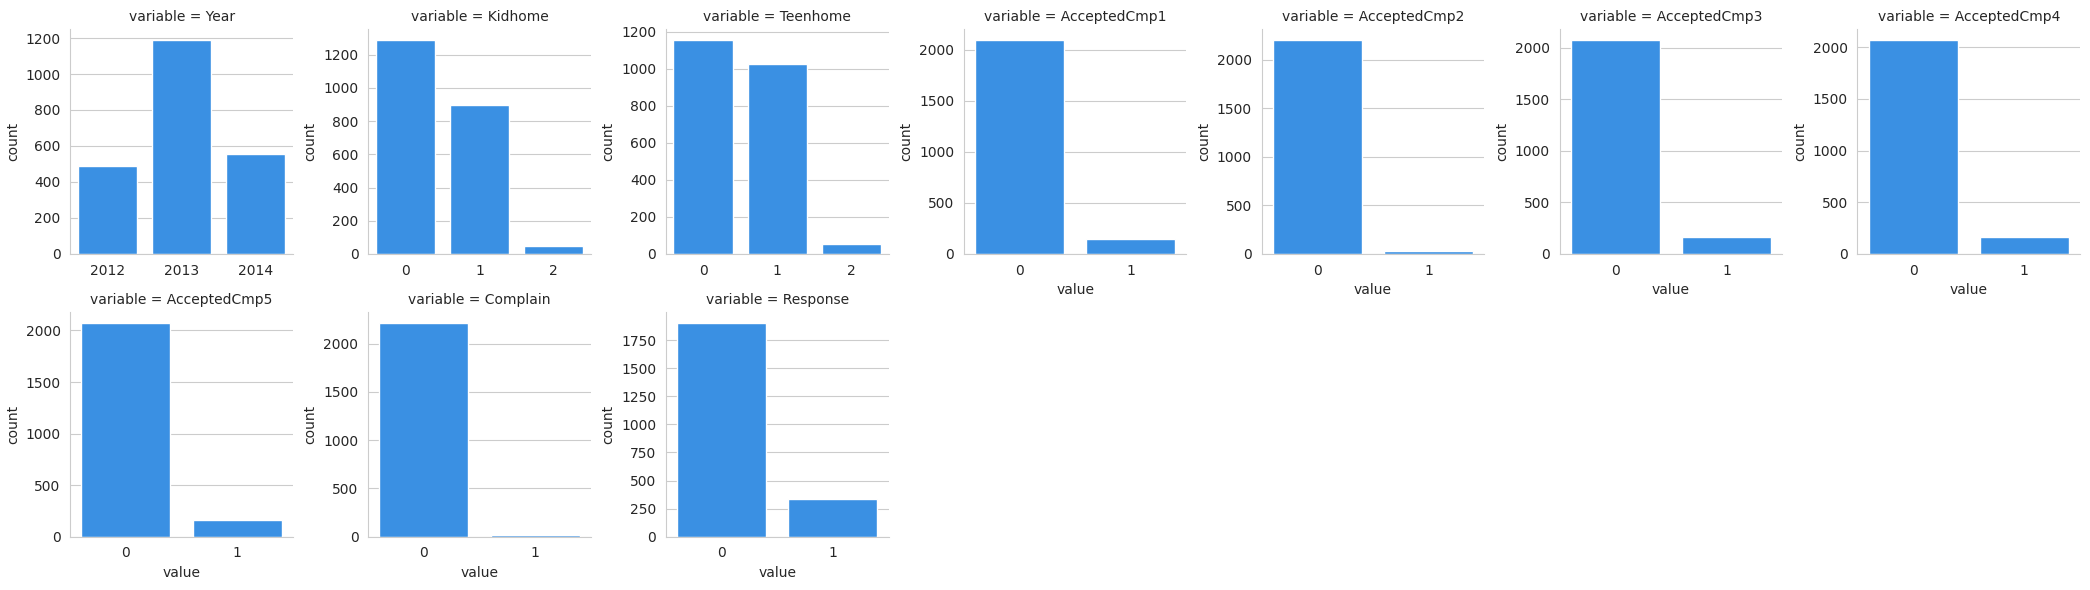

In [115]:
with sns.axes_style('whitegrid'):
  nd = pd.melt(df, value_vars=count_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=7, sharex=False, sharey=False)
  n1 = n1.map(sns.countplot, 'value', color='#1e90ff')

### Convert Categorical

#### Education

In [55]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [56]:
df = pd.get_dummies(df, columns=["Education"], prefix="Education", drop_first=False, dtype=int)

#### Marriage

In [57]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

"Alone" can be joined with "Single", 'Absurd' and 'YOLO' will be considered as noise and removed from the dataset

In [58]:
df["Marital_Status"] = df["Marital_Status"].replace({"Alone": "Single"})
df = df[~df["Marital_Status"].isin(["Absurd", "YOLO"])]

In [59]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      483
Divorced    232
Widow        77
Name: count, dtype: int64

In [62]:
df = pd.get_dummies(df, columns=["Marital_Status"], prefix="Marital_Status", drop_first=False, dtype=int)

#### Dt_Customer

In [60]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y', errors='coerce')
df['Year'] = df['Dt_Customer'].dt.year
df['Month'] = df['Dt_Customer'].dt.month
df['Day'] = df['Dt_Customer'].dt.day
df.drop("Dt_Customer", axis=1, inplace=True)

### Impute Missing Values

In [65]:
imputer = SimpleImputer()
df[:] = imputer.fit_transform(df)

Dropping columns with no change in values

In [79]:
df.drop("Z_CostContact", axis=1, inplace=True)

In [82]:
df.drop("Z_Revenue", axis=1, inplace=True)

In [136]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Year,Month,Day,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,...,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,1968.796512,52232.510850,0.444991,0.506261,49.147138,303.873435,26.271020,166.924419,37.405188,27.081395,...,0.165027,0.216458,2013.029070,6.464222,15.637299,0.103757,0.386404,0.216011,0.259392,0.034436
std,11.980604,25051.855691,0.538551,0.544615,28.954880,336.876776,39.761356,225.778550,54.436749,41.300943,...,0.371288,0.411922,0.683821,3.484330,8.797164,0.305013,0.487034,0.411614,0.438399,0.182388
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35502.500000,0.000000,0.000000,24.000000,23.000000,1.000000,16.000000,3.000000,1.000000,...,0.000000,0.000000,2013.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1970.000000,51741.500000,0.000000,0.000000,49.000000,173.000000,8.000000,67.000000,12.000000,8.000000,...,0.000000,0.000000,2013.000000,6.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1977.000000,68289.750000,1.000000,1.000000,74.000000,505.000000,33.000000,232.000000,50.000000,33.000000,...,0.000000,0.000000,2013.000000,10.000000,23.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,1.000000,1.000000,2014.000000,12.000000,31.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Preprocessing

In [85]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

### PCA

I tried doing silhouette analysis on all components, however the clustering was not good in such a high-dimensional space, so I decided to apply PCA to reduce the number of dimensions in hopes of achieving a better clustering and to drop columns that do not contribute towards explained variance ratio.

Instead of pruning outliers, I decided to partially reduce the variance to ~90% to see what number of clusters would be optimal.

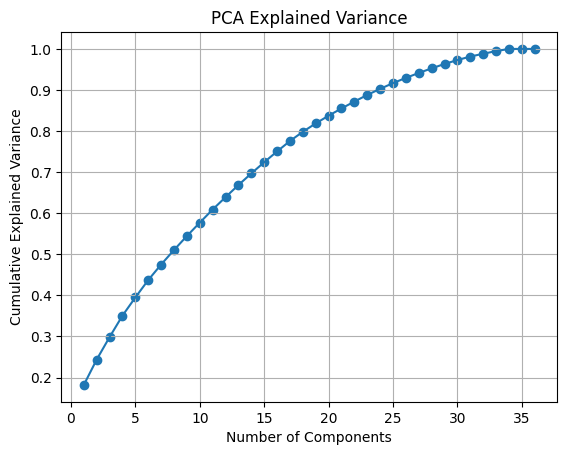

In [161]:
base_pca = PCA(n_components=len(X[0]))

base_pca.fit(X)

cumulative_variances = np.cumsum(base_pca.explained_variance_ratio_)

plt.plot(range(1, len(cumulative_variances) + 1), cumulative_variances)
plt.scatter(range(1, len(cumulative_variances) + 1), cumulative_variances)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()

### Silhouette Analysis

In [144]:
def draw_silhouette_plot(X, n_clusters, ax=None, title_prefix=""):
    clusterer = KMeans(n_clusters=n_clusters, random_state=999)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    if ax is None:
        ax = plt.gca()

    ax.set_xlim([-1, 1])
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    ax.set_yticks([])
    ax.set_xticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters)

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(f"{title_prefix}n_clusters={n_clusters} (SC: {silhouette_avg:.2f})")
    return silhouette_avg

#### Dependence of PCA number of components vs KMeans number of clusters in terms of Silhouette Score

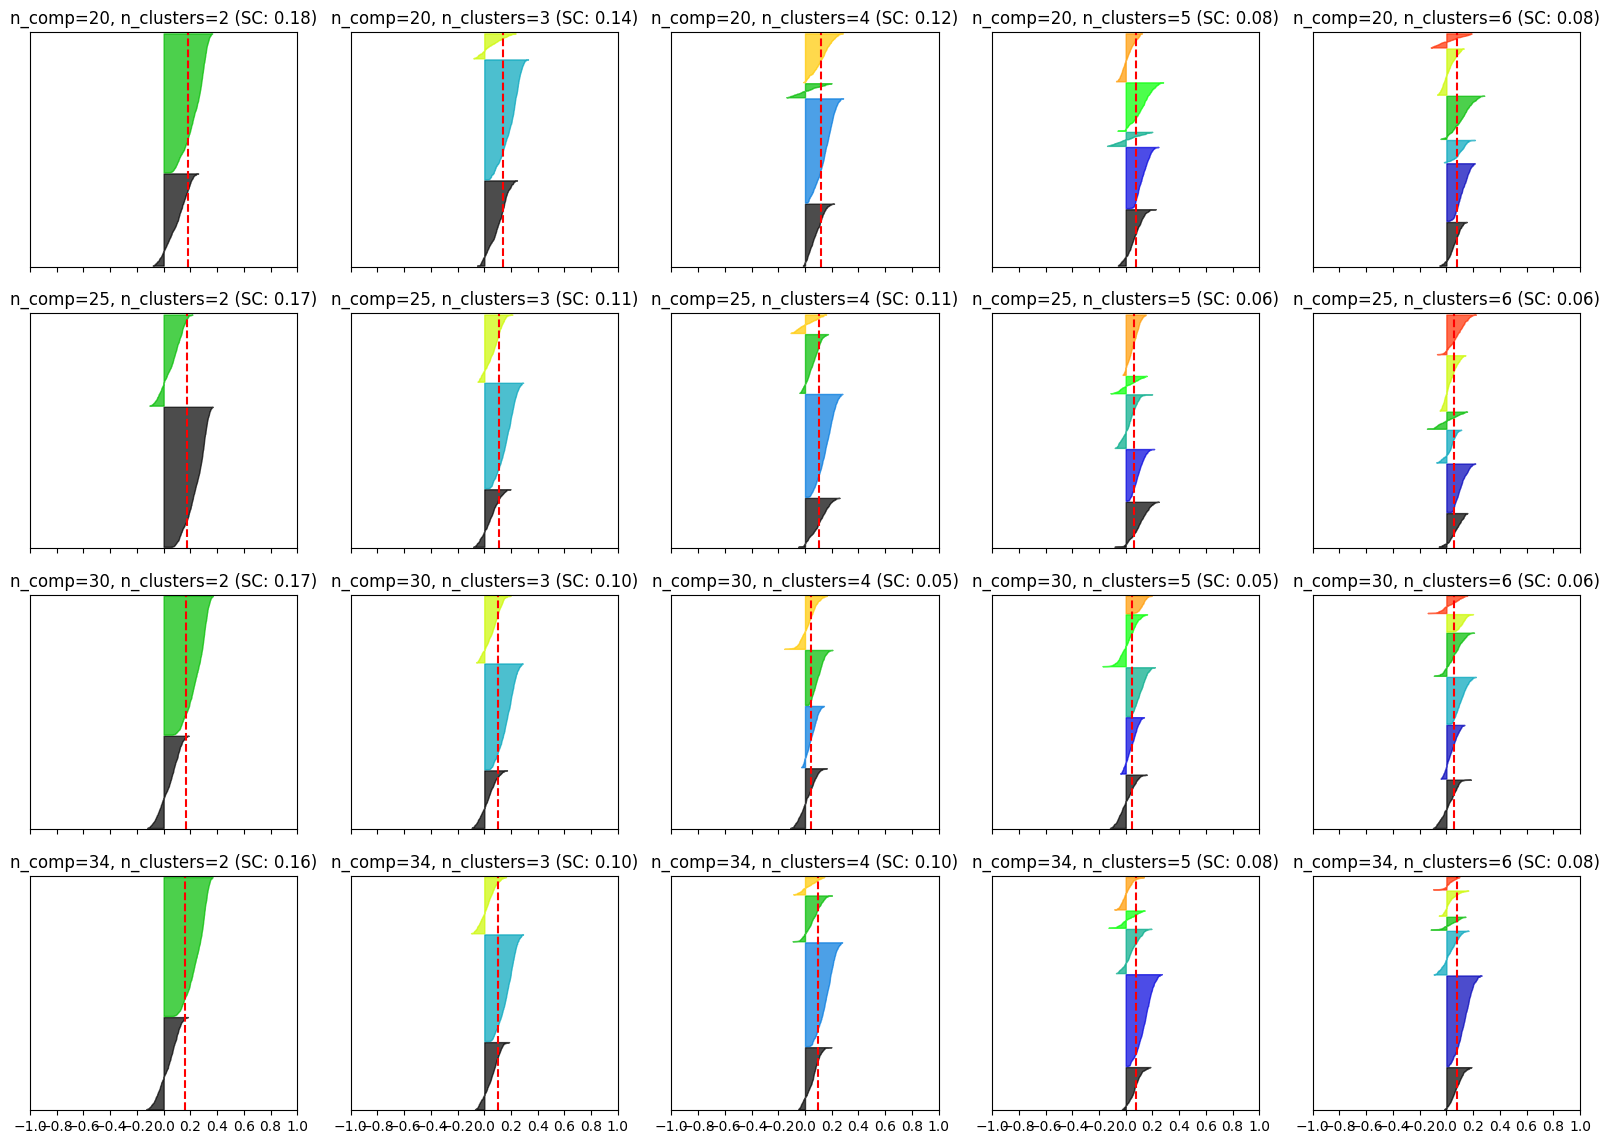

In [160]:
n_components_list = [20, 25, 30, 34]
range_n_clusters = [2, 3, 4, 5, 6]

fig, axes = plt.subplots(
    len(n_components_list),
    len(range_n_clusters),
    figsize=(4 * len(range_n_clusters), 3.5 * len(n_components_list)),
    sharex=True
)

for i, n_components in enumerate(n_components_list):
    pca_X = PCA(n_components=n_components, random_state=42).fit_transform(X)
    for j, k in enumerate(range_n_clusters):
        ax = axes[i, j]
        draw_silhouette_plot(pca_X, k, ax=ax, title_prefix=f"n_comp={n_components}, ")

#### Silhouette Analysis on Original Dataset

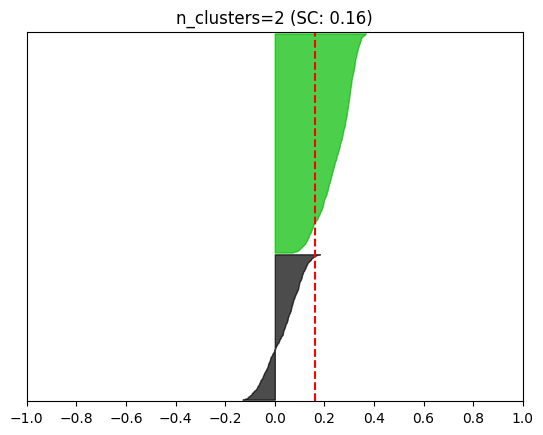

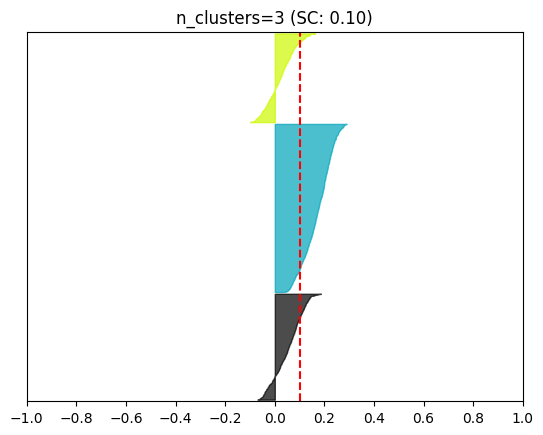

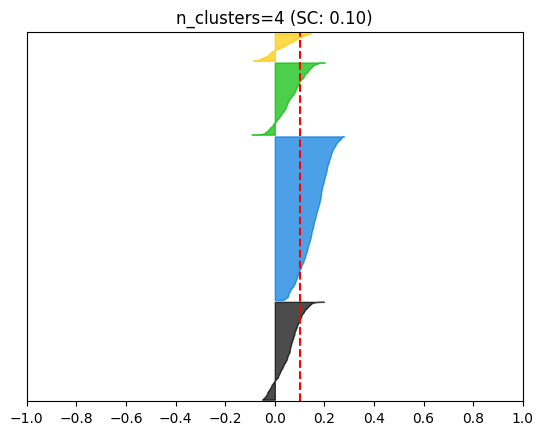

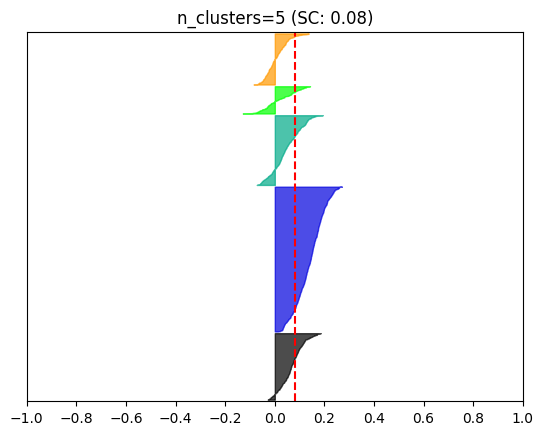

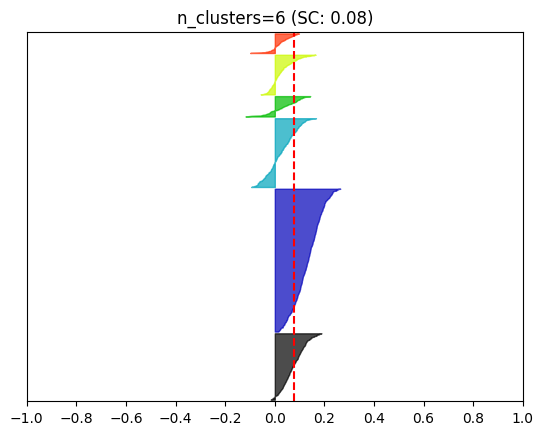

In [164]:
for i, k in enumerate([2, 3, 4, 5 ,6]):
    figure(i)
    draw_silhouette_plot(X, k)